## **0. Download dataset**
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

## **1. Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed(random_state)

## **2. Read dataset**

In [2]:
dataset_path = '../Data/[Data]_Ex1_Auto_MPG_data.csv'
dataset = pd.read_csv(dataset_path)
dataset

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0,1
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790.0,15.6,82,0,0,1
388,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
389,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
390,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1


## **3. Preprocessing data**

### **3.1. X, y split**

In [3]:
X = dataset.drop(columns='MPG').values
y = dataset['MPG'].values

### **3.2. Train/val/test split**

In [4]:
val_size = 0.2
test_size = 0.125
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=val_size,
    random_state=random_state,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)

In [5]:
print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of val samples: {X_val.shape[0]}')
print(f'Number of test samples: {X_test.shape[0]}')

Number of training samples: 273
Number of val samples: 79
Number of test samples: 40


### **3.3. Data Normalization**

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_train = torch.tensor(X_train, dtype=torch.float32)

X_val = scaler.transform(X_val)
X_val = torch.tensor(X_val, dtype=torch.float32)

X_test = scaler.transform(X_test)
X_test = torch.tensor(X_test, dtype=torch.float32)

## **4. Create PyTorch DataLoader**

In [7]:
### WRITE YOUR CODE HERE

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.data = X
        self.labels = y

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        return (self.data[idx, :], self.labels[idx])

In [8]:
# Create datasets for each set
train_set = CustomDataset(X_train, y_train)
val_set = CustomDataset(X_val, y_val)
test_set = CustomDataset(X_test, y_test)

In [9]:
train_set[0]

(tensor([-0.8414, -1.0379, -1.0381, -1.0061,  0.7828,  1.1191, -0.4443,  1.9045,
         -1.2748]),
 np.float64(46.6))

In [10]:
# Load the datasets into the dataloaders
train_loader = DataLoader(dataset=train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset=val_set, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=32,shuffle=True)

## **5. Build MLP network**

In [11]:
### WRITE YOUR CODE HERE

class MLP(nn.Module):
    def __init__(self, input_dims, hidden_dims, output_dims):
        super().__init__()
        self.layer1 = nn.Linear(input_dims, hidden_dims)
        self.layer2 = nn.Linear(hidden_dims, hidden_dims)
        self.output_layer = nn.Linear(hidden_dims, output_dims)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        output = self.output_layer(x)

        return output.squeeze(1)

In [12]:
input_dims, output_dims = X.shape[1], 1
hidden_dims = 64
model = MLP(input_dims, hidden_dims, output_dims)
model.to(device)

MLP(
  (layer1): Linear(in_features=9, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

## **6. Training**

In [13]:
def r_squared(y_true, y_pred):
    ### WRITE YOUR CODE HERE
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_mean = y_true.mean()
    ssr = ((y_true - y_pred)**2).sum()
    sst = ((y_true - y_mean)**2).sum()

    return 1 - ssr/sst

In [14]:
# Intilialize
epochs = 100
lr = 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [15]:
train_losses = []
train_r2 = []
val_losses = []
val_r2 = []

In [16]:
for epoch in range(epochs):
    train_loss = 0.0
    train_target = []
    val_target = []
    train_predict = []
    val_predict = []

    # Turn on training mode
    model.train()
    
    for X_samples, y_samples in train_loader:
        # Load data into GPU
        X_samples = X_samples.to(device)
        y_samples = y_samples.to(device)

        # Clear out gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_samples)
        train_predict += outputs.tolist()
        train_target += y_samples.tolist()

        # Calculate loss
        loss = criterion(outputs, y_samples)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()
        train_loss += loss.item() * len(X_samples)

    # Calulate total loss and r-squared
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    train_r2.append(r_squared(train_target, train_predict))

    # Switch to evaluation mode
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for X_samples, y_samples in val_loader:
            X_samples = X_samples.to(device)
            y_samples = y_samples.to(device)
            
            outputs = model(X_samples)
            val_predict += outputs.tolist()
            val_target += y_samples.tolist()
            
            loss = criterion(outputs, y_samples)
            val_loss += loss.item() * len(X_samples)
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_r2.append(r_squared(val_target, val_predict))
    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_loss:.3f}\tValidation loss: {val_loss:.3f}')


EPOCH 1:	Training loss: 8778.890	Validation loss: 2438.915

EPOCH 2:	Training loss: 6982.250	Validation loss: 374.116

EPOCH 3:	Training loss: 1680.589	Validation loss: 1814.914

EPOCH 4:	Training loss: 1777.377	Validation loss: 325.220

EPOCH 5:	Training loss: 472.922	Validation loss: 817.971

EPOCH 6:	Training loss: 425.698	Validation loss: 153.723

EPOCH 7:	Training loss: 433.869	Validation loss: 815.809

EPOCH 8:	Training loss: 597.587	Validation loss: 683.511

EPOCH 9:	Training loss: 465.559	Validation loss: 252.566

EPOCH 10:	Training loss: 604.924	Validation loss: 398.472

EPOCH 11:	Training loss: 553.439	Validation loss: 212.672

EPOCH 12:	Training loss: 323.780	Validation loss: 1074.833

EPOCH 13:	Training loss: 575.370	Validation loss: 345.003

EPOCH 14:	Training loss: 243.968	Validation loss: 429.814

EPOCH 15:	Training loss: 304.249	Validation loss: 166.020

EPOCH 16:	Training loss: 235.791	Validation loss: 139.761

EPOCH 17:	Training loss: 203.329	Validation loss: 147.313

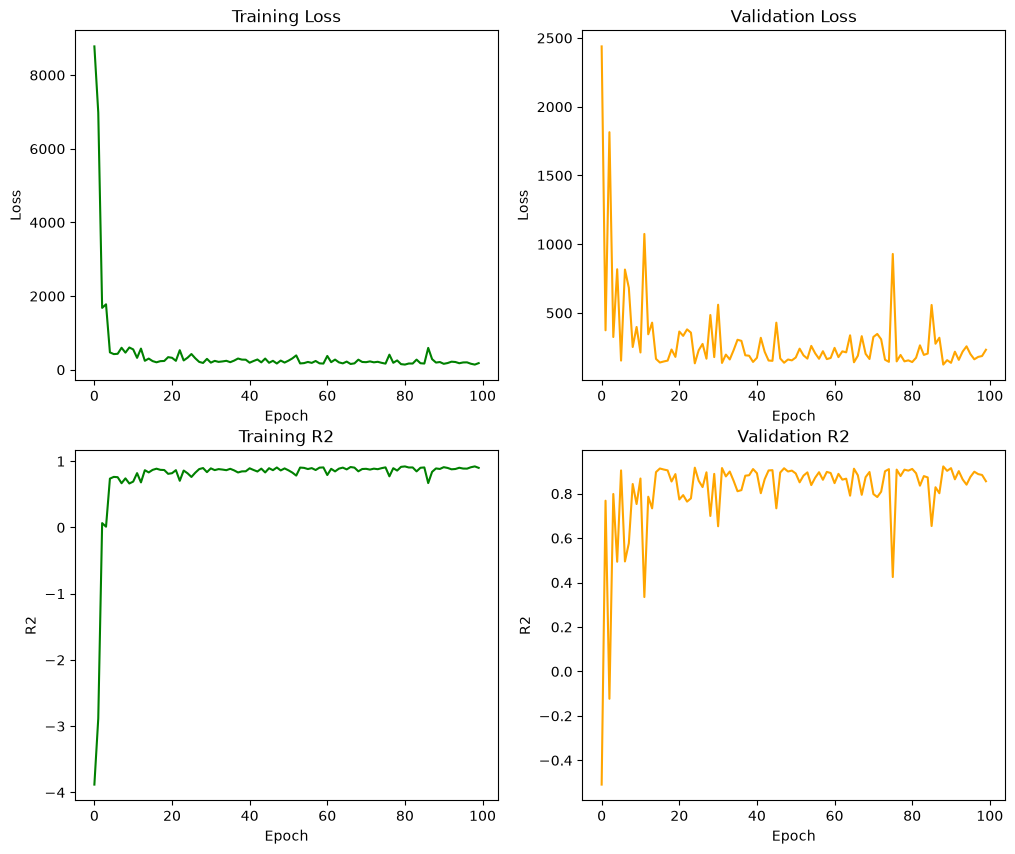

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_r2, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='R2')
ax[1, 0].set_title('Training R2')

ax[1, 1].plot(val_r2, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='R2')
ax[1, 1].set_title('Validation R2')

plt.show()

## **7. Evaluation**

In [18]:
model.eval()
with torch.no_grad():
    y_hat = model(X_val.to(device))
    y_hat = y_hat.tolist()
    val_set_r2 = r_squared(y_val, y_hat)
    print('Evaluation on validation set:')
    print(f'R2: {val_set_r2}')

Evaluation on validation set:
R2: 0.8560546558160819


In [19]:
model.eval()
with torch.no_grad():
    y_hat = model(X_test.to(device))
    y_hat = y_hat.tolist()
    test_set_r2 = r_squared(y_test, y_hat)
    print('Evaluation on test set:')
    print(f'R2: {test_set_r2}')

Evaluation on test set:
R2: 0.7962905321503867
